## Error Analysis: Nairobi House Prices

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [188]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [189]:
# load the dataset
df = pd.read_csv('data/nairobi_house_prices.csv')
df.head()

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN


## Data Cleaning and Preprocessing

In [190]:
# Explore the dataset: shape, missing values, duplicates, and numeric summaries
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData Types:\n", df.dtypes)

Shape: (204, 7)

Missing values:
 Price             0
propertyType      0
Location          0
Bedroom          21
bathroom         23
House size      105
Land size       140
dtype: int64

Duplicates: 30

Data Types:
 Price               str
propertyType        str
Location            str
Bedroom         float64
bathroom        float64
House size          str
Land size           str
dtype: object


In [191]:
# remove duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [192]:
# impute the missing values with the median for numeric columns and mode for categorical columns
for column in df.columns:
    if df[column].dtype == 'str':
        df[column] = df[column].fillna(df[column].mode()[0])
    elif df[column].dtype in ['int64', 'float64']:
        df[column] = df[column].fillna(df[column].median())

df.isnull().sum()

Price           0
propertyType    0
Location        0
Bedroom         0
bathroom        0
House size      0
Land size       0
dtype: int64

In [225]:
df.head(20)

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,350000000.0,Townhouse,Runda,4.0,4.0,150,0.50
1,30000000.0,Vacant Land,Karen,3.0,2.0,150,0.50
2,325000000.0,Vacant Land,Westlands,3.0,2.0,150,0.50
3,80000000.0,Townhouse,Kitisuru,5.0,5.0,150,0.50
4,25500000.0,Apartment,Kileleshwa,4.0,4.0,230,0.50
5,300000000.0,Townhouse,Runda,6.0,6.0,150,0.50
6,160000000.0,Townhouse,Runda,4.0,4.0,150,0.50
7,9500000.0,Apartment,Kilimani,2.0,2.0,105,0.50
8,150000000.0,Townhouse,Thigiri,4.0,4.0,150,0.50
9,42000000.0,Apartment,Kileleshwa,4.0,4.0,280,0.50


In [194]:
# convert land size and House size to numeric columns
df['Land size'] = pd.to_numeric(
    df['Land size'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)
df['House size'] = pd.to_numeric(
    df['House size'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

# clean Price: strip "Ksh", commas, spaces, then convert to numeric
df['Price'] = (
    df['Price']
    .str.replace(r'[^\d.]', '', regex=True)  # keep only digits and decimal points
    .astype(float)
)

df.head(10)

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,350000000.0,Townhouse,Runda,4.0,4.0,150,0.5
1,30000000.0,Vacant Land,Karen,3.0,2.0,150,0.5
2,325000000.0,Vacant Land,Westlands,3.0,2.0,150,0.5
3,80000000.0,Townhouse,Kitisuru,5.0,5.0,150,0.5
4,25500000.0,Apartment,Kileleshwa,4.0,4.0,230,0.5
5,300000000.0,Townhuse,Runda,6.0,6.0,150,0.5
6,160000000.0,Townhouse,Runda,4.0,4.0,150,0.5
7,9500000.0,Apartment,Kilimani,2.0,2.0,105,0.5
8,150000000.0,Townhouse,Thigiri,4.0,4.0,150,0.5
9,42000000.0,Apartment,Kileleshwa,4.0,4.0,280,0.5


In [195]:
# Standardise propertyType labels and inspect the distribution of each type
df['propertyType'] = df['propertyType'].replace({
    'Townhuse': 'Townhouse',
    'Town house': 'Townhouse'
})

df['propertyType'].value_counts()

propertyType
Apartment              92
Townhouse              65
Vacant Land            15
Commercial Property     1
Industrial Property     1
Name: count, dtype: int64

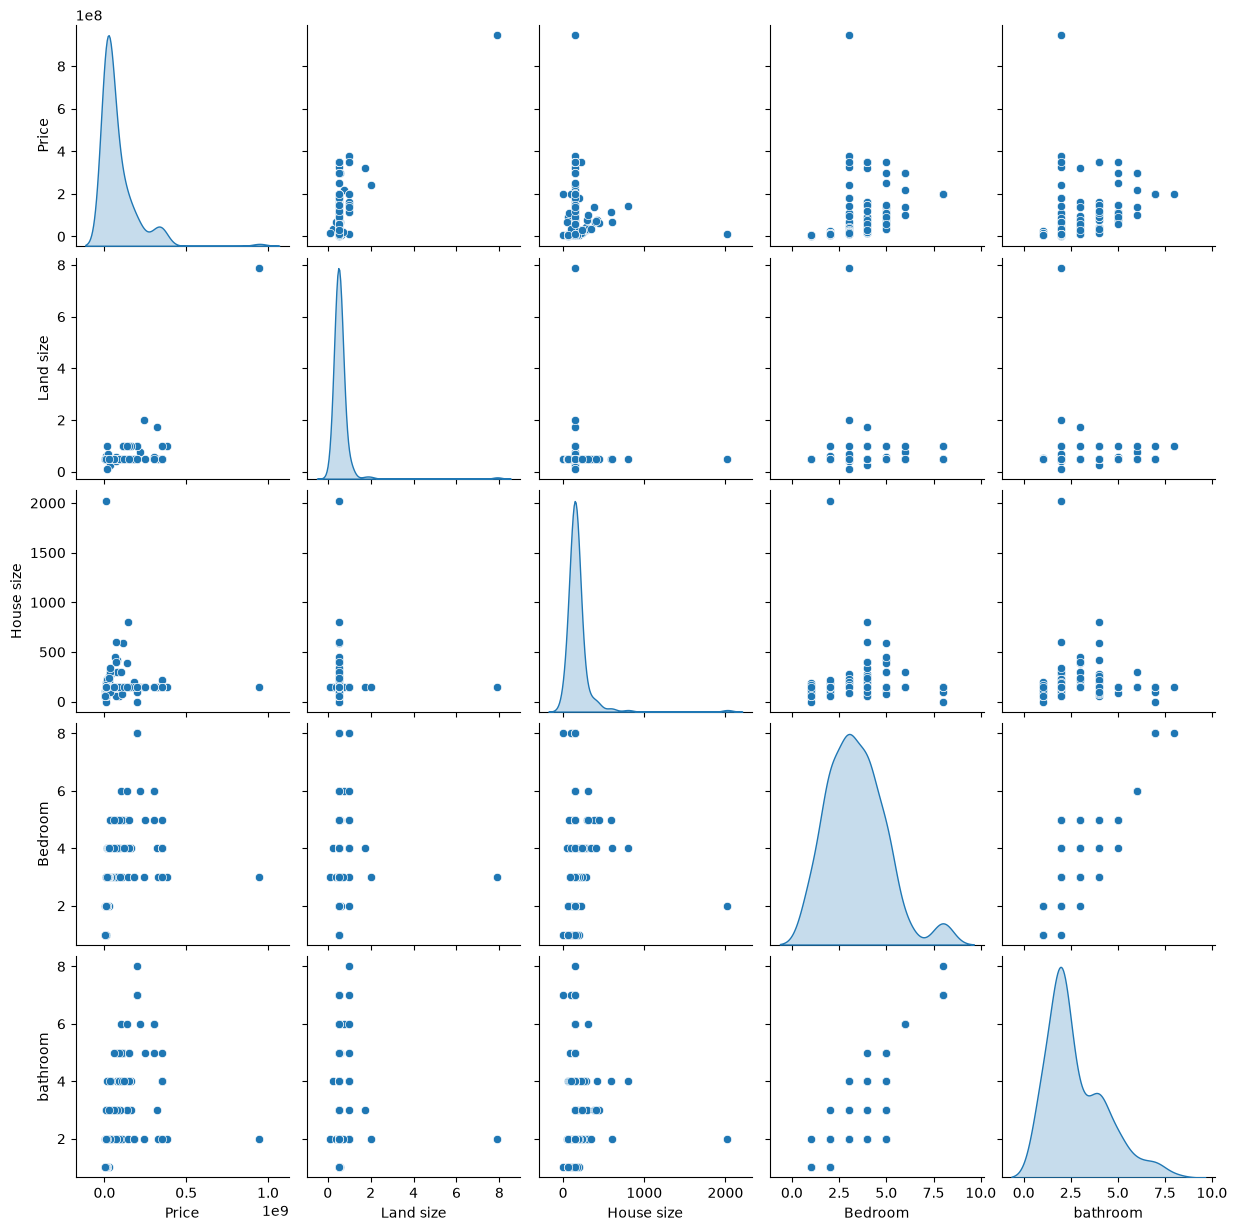

In [196]:
# plot a pairplot to visualize the relationships between numeric features and the target variable (Price)
sns.pairplot(
    df[['Price', 'Land size', 'House size', 'Bedroom', 'bathroom']],
    diag_kind='kde'   # or 'hist' for histograms instead of KDE curves
)
plt.show()

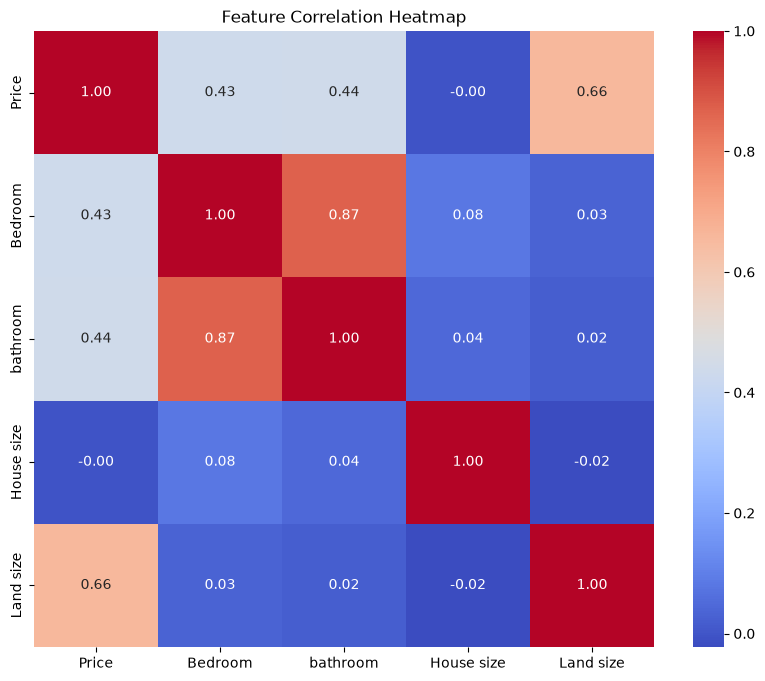

In [197]:
# feature correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

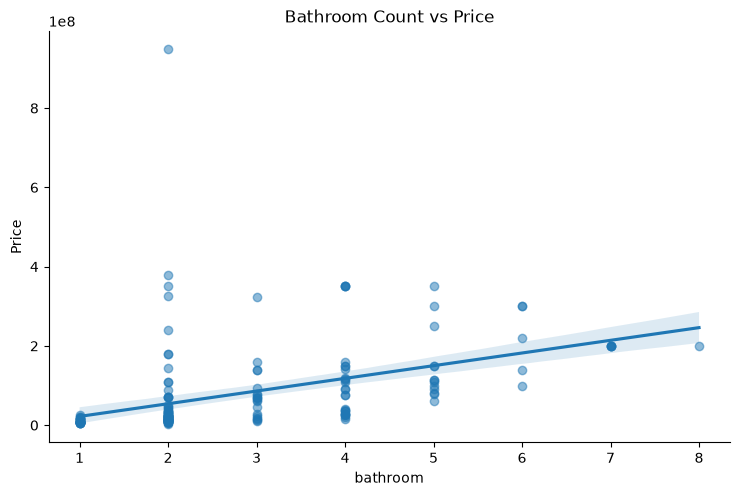

In [198]:
# check linearity of the relationship between features and target variable using sns.lmplot
sns.lmplot(x='bathroom', y='Price', data=df, aspect=1.5, scatter_kws={'alpha':0.5})
plt.title("Bathroom Count vs Price")
plt.show()

In [199]:
# split the dataset into features and target variable
X = df.drop(columns=['Price'])
y = df['Price']

# one-hot encode categorical variables
X = pd.get_dummies(X, columns=['propertyType', 'Location'], drop_first=True)

In [200]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [201]:
# model training and evaluation with linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](33,)","[ -607278.31, 6172212.63, 871.83,..., 4982730.95,13599522.08, 36940980.55]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](33,)","['Bedroom','bathroom','House size',...,'Location_Thome', 'Location_Waithaka','Location_Westlands']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-8.111e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,33
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,30


In [202]:
# scores
scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')

print("Cross-validated R^2 scores:", scores)
print("Mean R^2 score:", np.mean(scores))

Cross-validated R^2 scores: [0.51345301 0.82059516 0.52953787 0.48331458 0.43880191]
Mean R^2 score: 0.5571405078057428


In [203]:
# learning curve for linear regression
train_sizes, train_scores, val_scores = learning_curve(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

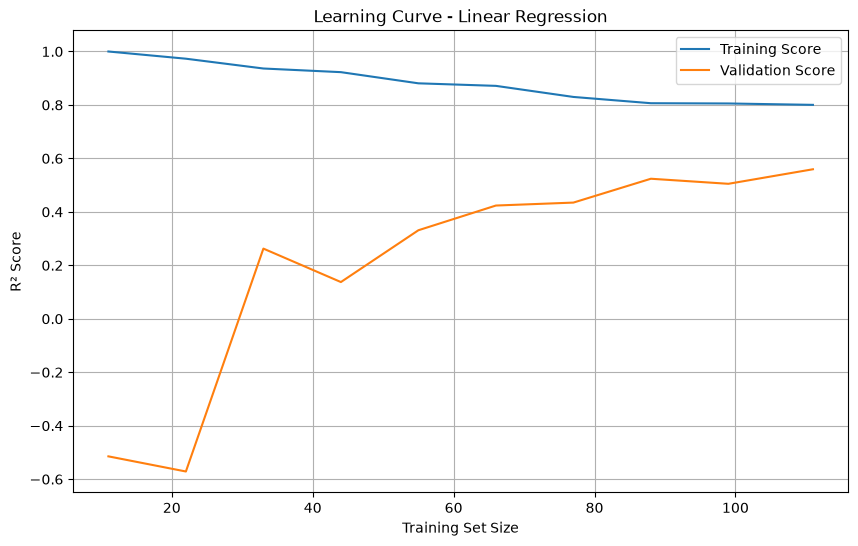

In [204]:
# plot the learning curve - linear regression
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Score")

plt.title("Learning Curve - Linear Regression")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid()
plt.show()

In [205]:
# add complexity Polynomial Regression
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('linear', LinearRegression())
])

scores = cross_val_score(
    poly_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Polynomial Regression R² scores:", scores)
print("Polynomial (degree=1) R²:", scores.mean())

Polynomial Regression R² scores: [0.51345301 0.82059516 0.52953787 0.48331458 0.43880191]
Polynomial (degree=1) R²: 0.5571405078057323


In [206]:
# add complexity Polynomial Regression degree=2
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

scores = cross_val_score(
    poly_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Polynomial Regression R² scores:", scores)
print("Polynomial (degree=2) R²:", scores.mean())

Polynomial Regression R² scores: [-2.06741553 -0.00947436  0.61098911  0.49960822  0.55799768]
Polynomial (degree=2) R²: -0.08165897660266586


In [207]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

from scipy.stats import randint, uniform
param_dist = {
    'poly__degree': randint(1, 4),
    'ridge__alpha': uniform(0.01, 10)
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print("Best Parameters (Random Search):")
print(random_search.best_params_)

print("Best CV Score:", random_search.best_score_)

Best Parameters (Random Search):
{'poly__degree': 2, 'ridge__alpha': np.float64(1.5699452033620265)}
Best CV Score: 0.6808320202386499


## Error Analysis

In [208]:
best_model = random_search.best_estimator_

In [209]:
y_pred = best_model.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

Test R²: 0.7538506918621777


In [210]:
errors = y_test - y_pred

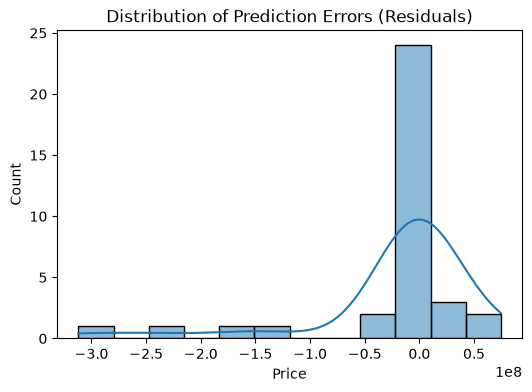

In [211]:
plt.figure(figsize=(6,4))
sns.histplot(errors, kde=True)
plt.title("Distribution of Prediction Errors (Residuals)")
plt.show()

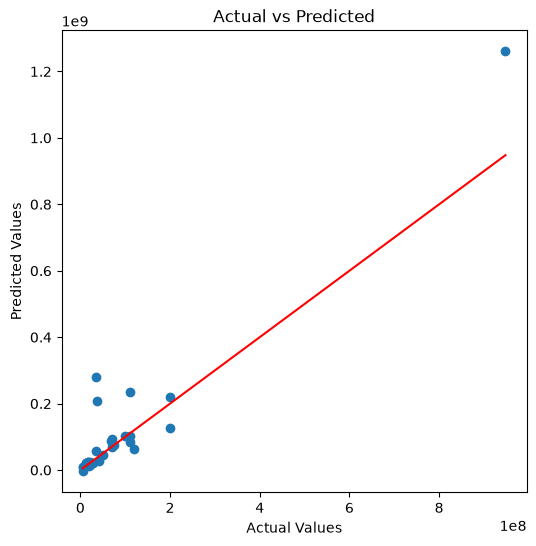

In [212]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()

In [213]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Error": errors,
    "Abs_Error": np.abs(errors)
})

results.sort_values(by="Abs_Error", ascending=False).head(10)

,Actual,Predicted,Error,Abs_Error
76,948000000.0,1.260035e+09,-3.120351e+08,3.120351e+08
12,35000000.0,2.802218e+08,-2.452218e+08,2.452218e+08
27,38000000.0,2.081314e+08,-1.701314e+08,1.701314e+08
172,110000000.0,2.358598e+08,-1.258598e+08,1.258598e+08
46,200000000.0,1.252937e+08,7.470626e+07,7.470626e+07
182,120000000.0,6.291325e+07,5.708675e+07,5.708675e+07
126,110000000.0,8.438648e+07,2.561352e+07,2.561352e+07
194,35000000.0,5.772031e+07,-2.272031e+07,2.272031e+07
34,70000000.0,9.238685e+07,-2.238685e+07,2.238685e+07
47,68000000.0,8.751148e+07,-1.951148e+07,1.951148e+07


In [222]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Error": y_test.values - y_pred,
    "Abs_Error": np.abs(y_test.values - y_pred)
})

In [223]:
results_with_features = X_test.copy()
results_with_features["Actual"] = y_test.values
results_with_features["Predicted"] = y_pred
results_with_features["Error"] = y_test.values - y_pred
results_with_features["Abs_Error"] = np.abs(y_test.values - y_pred)

In [224]:
worst_cases = results_with_features.sort_values(by="Abs_Error", ascending=False).head(10)
worst_cases

,Bedroom,bathroom,House size,Land size,propertyType_Commercial Property,propertyType_Industrial Property,propertyType_Townhouse,propertyType_Vacant Land,Location_Karen,Location_Kiambu Road,...,Location_Runda,Location_Syokimau,Location_Thigiri,Location_Thome,Location_Waithaka,Location_Westlands,Actual,Predicted,Error,Abs_Error
76,3.0,2.0,150,7.90,False,False,False,True,False,False,...,False,False,False,False,False,False,948000000.0,1.260035e+09,-3.120351e+08,3.120351e+08
12,4.0,4.0,150,0.25,False,False,True,False,False,False,...,True,False,False,False,False,False,35000000.0,2.802218e+08,-2.452218e+08,2.452218e+08
27,4.0,4.0,150,0.50,False,False,True,False,False,False,...,False,False,False,False,False,False,38000000.0,2.081314e+08,-1.701314e+08,1.701314e+08
172,5.0,4.0,75,0.50,False,False,True,False,False,False,...,True,False,False,False,False,False,110000000.0,2.358598e+08,-1.258598e+08,1.258598e+08
46,8.0,7.0,1,0.50,False,False,True,False,False,False,...,True,False,False,False,False,False,200000000.0,1.252937e+08,7.470626e+07,7.470626e+07
182,4.0,4.0,150,0.50,False,False,True,False,False,False,...,False,False,False,False,False,False,120000000.0,6.291325e+07,5.708675e+07,5.708675e+07
126,5.0,2.0,150,0.50,False,False,True,False,False,False,...,False,False,False,False,False,False,110000000.0,8.438648e+07,2.561352e+07,2.561352e+07
194,4.0,4.0,95,0.50,False,False,True,False,False,False,...,False,False,False,False,False,False,35000000.0,5.772031e+07,-2.272031e+07,2.272031e+07
34,3.0,2.0,150,0.56,False,False,False,True,False,False,...,False,False,False,False,False,False,70000000.0,9.238685e+07,-2.238685e+07,2.238685e+07
47,4.0,3.0,399,0.50,False,False,True,False,False,False,...,False,False,False,False,False,False,68000000.0,8.751148e+07,-1.951148e+07,1.951148e+07


In [217]:
import lime
from lime.lime_tabular import LimeTabularExplainer

In [218]:
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    mode='regression'
)
from IPython.display import display, HTML
explanation = explainer.explain_instance(
    data_row=np.array(X_test.iloc[0]),
    predict_fn=best_model.predict,
)
display(HTML(explanation.as_html(show_predicted_value=False)))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Background dataset has 139 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=139 when initializing the masker.
/var/folders/2y/rw1f6sdn1_z84ny_s3mlv_1w0000gn/T/ipykernel_52625/3940895609.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test.astype(float), feature_names=X_test.columns, plot_type="bar")


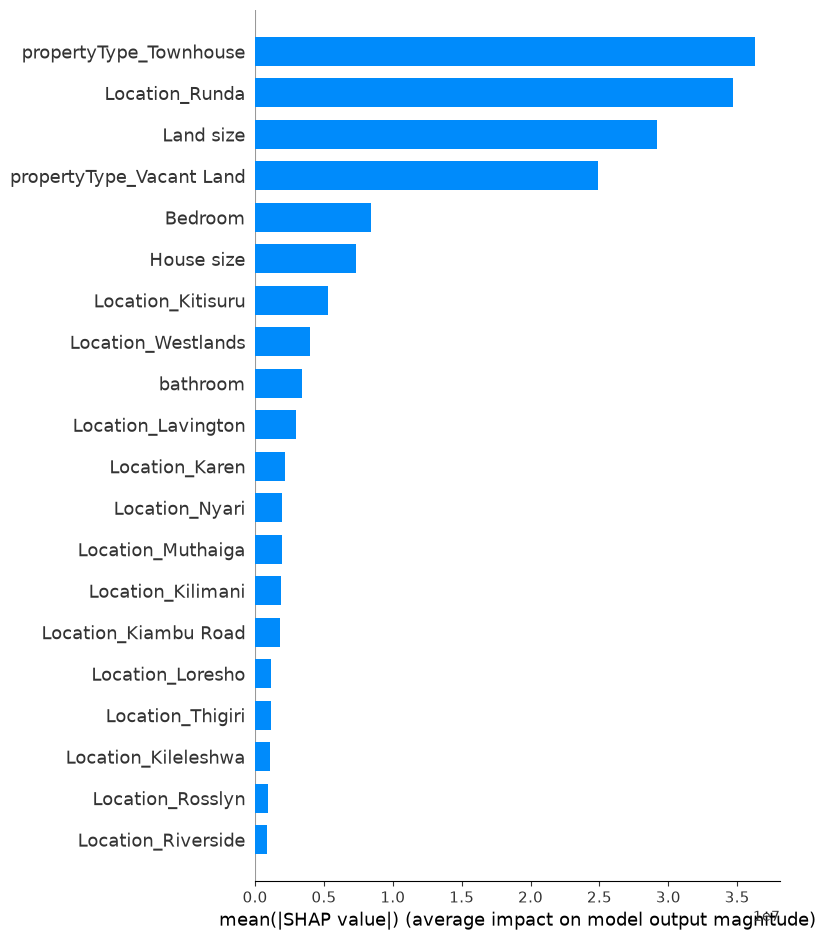

In [221]:
# using SHAP
import shap
masker = shap.maskers.Independent(X_train.astype(float))
explainer = shap.Explainer(best_model.predict, masker)
shap_values = explainer(X_test.astype(float))
shap.summary_plot(shap_values, X_test.astype(float), feature_names=X_test.columns, plot_type="bar")